<a href="https://colab.research.google.com/github/MohammedKQ/deep-learning-mini-project/blob/main/Yasir_DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECG Heartbeat Classification with ANN

This notebook applies an **Artificial Neural Network (ANN)** to classify ECG heartbeat signals.
The workflow covers data loading, quick exploration, preprocessing, manual hyperparameter tuning,
final training, model saving/loading, and evaluation on the test set.


## 1) Import Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2) Load the Training and Test Datasets


In [ ]:
test_df = pd.read_csv('/content/mitbih_test.csv')
test_df.head()


,1.000000000000000000e+00,7.582644820213317871e-01,1.115702465176582336e-01,0.000000000000000000e+00,8.057851344347000122e-02,7.851240038871765137e-02,6.611569970846176147e-02,4.958677664399147034e-02,4.752065986394882202e-02,3.512396663427352905e-02,...,0.000000000000000000e+00.56,0.000000000000000000e+00.57,0.000000000000000000e+00.58,0.000000000000000000e+00.59,0.000000000000000000e+00.60,0.000000000000000000e+00.61,0.000000000000000000e+00.62,0.000000000000000000e+00.63,0.000000000000000000e+00.64,0.000000000000000000e+00.65
0,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.000000,0.923664,0.656489,0.195929,0.111959,0.175573,0.122137,0.050891,0.035623,0.055980,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df = pd.read_csv('/content/mitbih_train.csv')
train_df.head()


,9.779411554336547852e-01,9.264705777168273926e-01,6.813725233078002930e-01,2.450980395078659058e-01,1.544117629528045654e-01,1.911764740943908691e-01,1.519607901573181152e-01,8.578431606292724609e-02,5.882352963089942932e-02,4.901960864663124084e-02,...,0.000000000000000000e+00.79,0.000000000000000000e+00.80,0.000000000000000000e+00.81,0.000000000000000000e+00.82,0.000000000000000000e+00.83,0.000000000000000000e+00.84,0.000000000000000000e+00.85,0.000000000000000000e+00.86,0.000000000000000000e+00.87,0.000000000000000000e+00.88
0,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.927461,1.000000,0.626943,0.193437,0.094991,0.072539,0.043178,0.053541,0.093264,0.189983,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3) Quick Data Exploration


In [ ]:
train_df.shape


(87553, 188)

In [ ]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87553 entries, 0 to 87552
Columns: 188 entries, 9.779411554336547852e-01 to 0.000000000000000000e+00.88
dtypes: float64(188)
memory usage: 125.6 MB


In [ ]:
train_df.isnull().sum().sum()


np.int64(0)

In [ ]:
train_df.duplicated().sum()


np.int64(0)

## 4) Separate Features and Target


In [ ]:
features = train_df.iloc[:, :-1].values
target = train_df.iloc[:, -1].values


In [ ]:
print("Features shape:", features.shape)
print("Target shape:", target.shape)


Features shape: (87553, 187)
Target shape: (87553,)


## 5) Encode Labels and Create a Validation Split


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

label_encoder = LabelEncoder()
encoded_target = label_encoder.fit_transform(target)

print("Encoded target shape:", encoded_target.shape)
print("Classes:", np.unique(encoded_target))


Encoded target shape: (87553,)
Classes: [0 1 2 3 4]


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    features,
    encoded_target,
    test_size=0.2,
    random_state=42,
    stratify=encoded_target
)


## 6) Standardize the Features


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


## 7) Prepare the Test Set


In [ ]:
X_test = test_df.iloc[:, :-1].values
y_test_raw = test_df.iloc[:, -1].values

y_test = label_encoder.transform(y_test_raw)
X_test = scaler.transform(X_test)

print("Test classes:", np.unique(y_test))


Test classes: [0 1 2 3 4]


## 8) Import Modeling Utilities


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from keras.optimizers import Adam


## 9) Build the ANN Model


In [ ]:
def build_model(first_units=512, second_units=256, dropout_rate=0.3, learning_rate=0.001):
    model = Sequential([
        Dense(first_units, input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.3),
        Dropout(dropout_rate),

        Dense(second_units),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.3),
        Dropout(dropout_rate),

        Dense(128),
        BatchNormalization(),
        LeakyReLU(negative_slope=0.3),

        Dense(len(np.unique(y_train)), activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


## 10) Manual Hyperparameter Tuning


In [ ]:
candidate_settings = [
    {"first_units": 256, "second_units": 128, "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 32},
    {"first_units": 512, "second_units": 256, "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 32},
    {"first_units": 512, "second_units": 256, "dropout_rate": 0.5, "learning_rate": 0.001, "batch_size": 32},
    {"first_units": 512, "second_units": 256, "dropout_rate": 0.3, "learning_rate": 0.0005, "batch_size": 64},
]

tuning_results = []

for trial_number, settings in enumerate(candidate_settings, start=1):
    print(f"\n--- Trial {trial_number}: {settings} ---")

    candidate_model = build_model(
        first_units=settings["first_units"],
        second_units=settings["second_units"],
        dropout_rate=settings["dropout_rate"],
        learning_rate=settings["learning_rate"]
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    training_history = candidate_model.fit(
        X_train,
        y_train,
        validation_data=(X_valid, y_valid),
        epochs=50,
        batch_size=settings["batch_size"],
        callbacks=[early_stopping],
        verbose=0
    )

    tuning_results.append({
        "trial": trial_number,
        **settings,
        "best_val_accuracy": max(training_history.history["val_accuracy"]),
        "best_val_loss": min(training_history.history["val_loss"])
    })

results_df = pd.DataFrame(tuning_results).sort_values(
    by="best_val_accuracy",
    ascending=False
)

results_df



--- Trial 1: {'first_units': 256, 'second_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32} ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Restoring model weights from the end of the best epoch: 49.

--- Trial 2: {'first_units': 512, 'second_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32} ---
Restoring model weights from the end of the best epoch: 47.

--- Trial 3: {'first_units': 512, 'second_units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 32} ---
Restoring model weights from the end of the best epoch: 47.

--- Trial 4: {'first_units': 512, 'second_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64} ---
Restoring model weights from the end of the best epoch: 48.


,trial,first_units,second_units,dropout_rate,learning_rate,batch_size,best_val_accuracy,best_val_loss
3,4,512,256,0.3,0.0005,64,0.982868,0.062405
1,2,512,256,0.3,0.0010,32,0.982011,0.061620
0,1,256,128,0.3,0.0010,32,0.980869,0.067817
2,3,512,256,0.5,0.0010,32,0.978870,0.073480


## 11) Train the Final Model with the Best Settings


In [ ]:
best_settings = results_df.iloc[0].to_dict()

print("Best configuration:")
print(best_settings)

final_model = build_model(
    first_units=int(best_settings["first_units"]),
    second_units=int(best_settings["second_units"]),
    dropout_rate=float(best_settings["dropout_rate"]),
    learning_rate=float(best_settings["learning_rate"])
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=int(best_settings["batch_size"]),
    callbacks=[early_stopping],
    verbose=1
)


Best configuration:
{'trial': 4.0, 'first_units': 512.0, 'second_units': 256.0, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64.0, 'best_val_accuracy': 0.9828678965568542, 'best_val_loss': 0.06240524351596832}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9189 - loss: 0.2950 - val_accuracy: 0.9567 - val_loss: 0.1631
Epoch 2/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9506 - loss: 0.1740 - val_accuracy: 0.9635 - val_loss: 0.1250
Epoch 3/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9568 - loss: 0.1525 - val_accuracy: 0.9657 - val_loss: 0.1178
Epoch 4/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9601 - loss: 0.1404 - val_accuracy: 0.9697 - val_loss: 0.1085
Epoch 5/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9640 - loss: 0.1285 - val_accuracy: 0.9717 - val_loss: 0.0986
Epoch 6/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9650 - loss: 0.1222 - val_accuracy: 0.9720 - val_loss: 0.0985
Epoch 7/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9678 - loss: 0.1153 - val_accuracy: 0.9716 - val_loss: 0.0992
Epoch 8/100
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 

## 12) Visualize the Training History


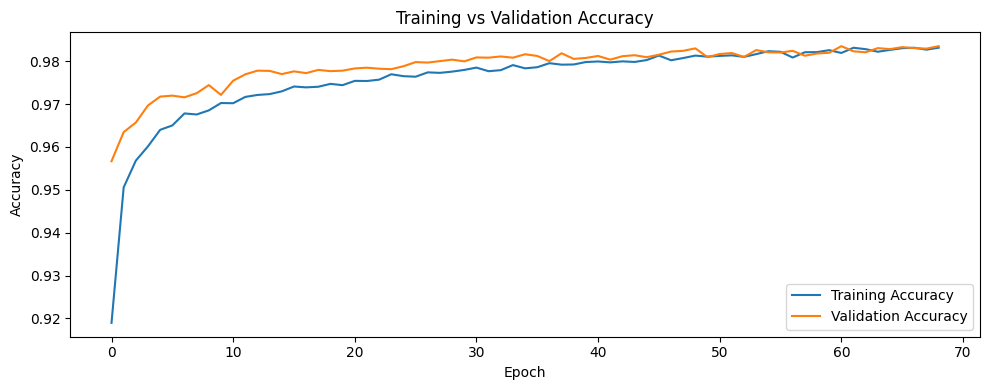

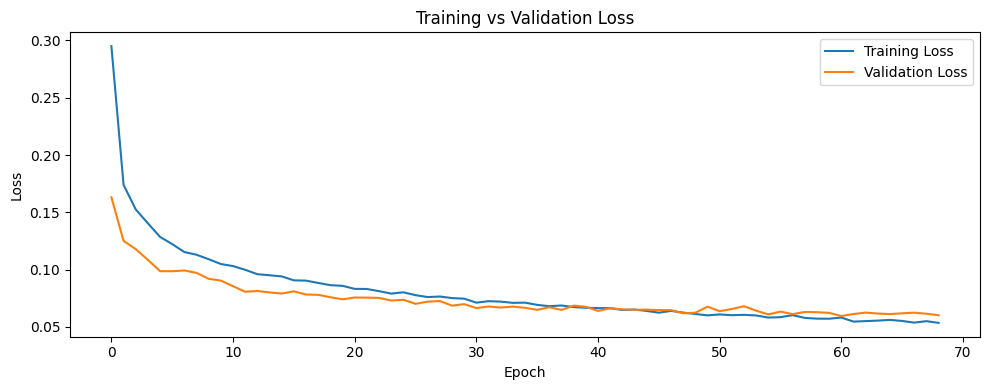

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


## 13) Save and Reload the Model


In [ ]:
final_model.save("ecg_ann_model.keras")
loaded_model = load_model("ecg_ann_model.keras")

print("Model saved and loaded successfully.")


Model saved and loaded successfully.


In [ ]:
sample_indices = np.random.choice(len(X_test), 5, replace=False)

original_predictions = np.argmax(final_model.predict(X_test[sample_indices], verbose=0), axis=1)
reloaded_predictions = np.argmax(loaded_model.predict(X_test[sample_indices], verbose=0), axis=1)

print("Original predictions:", original_predictions)
print("Reloaded predictions:", reloaded_predictions)
print("Predictions match:", np.array_equal(original_predictions, reloaded_predictions))


Original predictions: [0 4 0 0 0]
Reloaded predictions: [0 4 0 0 0]
Predictions match: True


## 14) Final Evaluation on the Test Set


In [ ]:
test_loss, test_accuracy = loaded_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Loss: 0.0736
Test Accuracy: 98.06%


In [ ]:
y_pred = np.argmax(loaded_model.predict(X_test, verbose=0), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18117
           1       0.89      0.71      0.79       556
           2       0.96      0.94      0.95      1448
           3       0.81      0.75      0.78       162
           4       0.99      0.98      0.98      1608

    accuracy                           0.98     21891
   macro avg       0.93      0.87      0.90     21891
weighted avg       0.98      0.98      0.98     21891



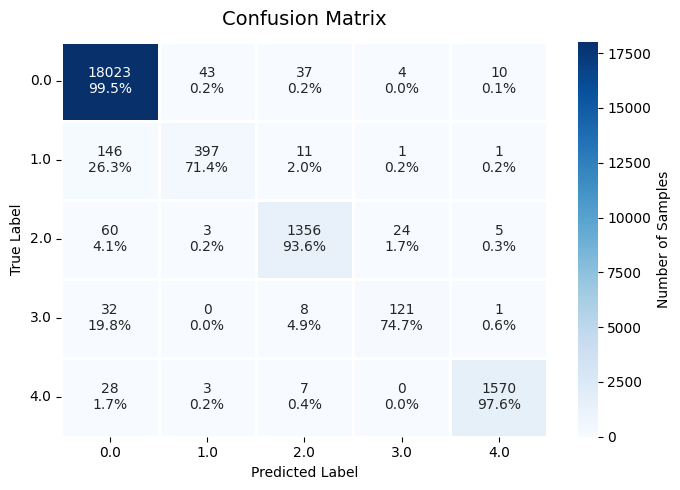

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

row_percentages = conf_matrix.astype(float) / conf_matrix.sum(axis=1, keepdims=True) * 100
annotation_labels = np.array([
    [
        f"{count}\n{percentage:.1f}%"
        for count, percentage in zip(row_counts, row_percentages_row)
    ]
    for row_counts, row_percentages_row in zip(conf_matrix, row_percentages)
])

plt.figure(figsize=(7, 5))
heatmap = sns.heatmap(
    conf_matrix,
    annot=annotation_labels,
    fmt="",
    cmap="Blues",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Number of Samples"},
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

heatmap.set_title("Confusion Matrix", fontsize=14, pad=12)
heatmap.set_xlabel("Predicted Label")
heatmap.set_ylabel("True Label")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
